# 02 — Feature Engineering

Build the feature pipeline: KenPom deltas, context features, and per-expert ranking targets.
Visualize distributions, correlations, and leakage-safe split behavior.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Load Merged Data

In [2]:
from src.data.merge import merge_kenpom_with_matchups

merged = merge_kenpom_with_matchups()
print(f"Shape: {merged.shape}")
print(f"Seasons: {merged['season'].min()} - {merged['season'].max()}")
print(f"Total games: {len(merged)}")
print(f"Higher seed win rate: {merged['higher_seed_won'].mean():.3f}")
merged.head()

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:Loading pomeroy ratings from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/cache/kenpom_pomeroy_ratings.parquet
INFO:src.data.kaggle_loader:Loaded pomeroy ratings: 8679 rows, 25 seasons
INFO:src.data.kaggle_loader:Pomeroy merge: 7607/8315 matched. 708 unmatched (mostly non-tournament): ['Miami', 'Pennsylvania', 'Little Rock', 'McNeese', 'IU Indianapolis', 'Sam Houston', 'Missouri State', 'Louisiana', 'Miami (OH)', 'Charleston']
INFO:src.data.kaggle_loader:Final KenPom dataset: 8314 rows, 43 columns, seasons 2002–2025
INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)
INFO:src.data.merge:Merge comple

Shape: (1388, 80)
Seasons: 2003 - 2025
Total games: 1388
Higher seed win rate: 0.712


,season,round,region,seed_a,team_id_a,team_name_a,score_a,seed_b,team_id_b,team_name_b,score_b,higher_seed_won,off_efgpct_a,off_topct_a,off_orpct_a,off_ftrate_a,adjtempo_a,adjoe_a,adjde_a,adjem_a,off_fg2pct_a,off_fg3pct_a,off_ftpct_a,off_blockpct_a,def_fg2pct_a,...,off_fg3pct_b,off_ftpct_b,off_blockpct_b,def_fg2pct_b,def_fg3pct_b,def_ftpct_b,def_blockpct_b,off_fg3rate_b,def_fg3rate_b,off_arate_b,def_arate_b,off_stlrate_b,def_stlrate_b,off_nstrate_b,def_nstrate_b,avg_height_b,eff_height_b,experience_b,bench_b,net_rating_b,luck_b,sos_adjem_b,sos_opp_o_b,sos_opp_d_b,ncsos_adjem_b
0,2003,1,Z,1,1112,Arizona,80,16,1436,Vermont,51,1,51.4922,19.0144,39.2726,36.8072,73.0165,115.311,88.8866,26.4243,50.8186,35.3488,70.9138,9.5506,44.6629,...,33.7634,65.9722,8.7512,47.0993,32.8173,67.5906,9.3081,27.6951,38.8455,57.1622,59.0449,0.1052,0.1087,NaN,NaN,NaN,NaN,NaN,NaN,1.6,0.019,-5.14,99.3,104.4,-2.29
1,2003,1,W,1,1328,Oklahoma,71,16,1354,S Carolina St,54,1,51.1506,18.6599,36.5739,32.9498,62.6863,112.913,89.4266,23.4861,47.3312,39.1850,69.2063,9.2620,44.4277,...,33.2645,69.9488,7.8345,45.6866,34.4037,65.3491,8.0833,28.7411,36.5363,41.3072,50.8065,0.1095,0.1335,NaN,NaN,NaN,NaN,NaN,NaN,-8.6,0.115,-12.27,95.2,107.5,-0.55
2,2003,1,Y,1,1246,Kentucky,95,16,1237,IUPUI,64,1,53.7583,20.0752,39.6918,35.2997,67.5518,116.802,87.0347,29.7672,53.9222,35.5556,70.3504,12.9412,45.2941,...,34.7541,69.4040,5.0341,54.3515,36.3339,67.4380,10.6293,34.1545,34.2681,54.4776,62.5146,0.1178,0.0977,NaN,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN
3,2003,1,X,1,1400,Texas,82,16,1421,UNC Asheville,61,1,49.3431,18.3702,41.5476,39.8054,69.0435,118.524,95.1369,23.3866,47.8405,35.6364,72.1271,8.7050,44.2446,...,35.6643,75.9690,7.4519,50.2404,36.8259,66.6667,10.3648,32.1710,34.2119,52.4934,56.6975,0.0990,0.1212,NaN,NaN,NaN,NaN,NaN,NaN,-12.3,0.119,-6.45,98.3,104.7,11.61
4,2003,1,Z,2,1242,Kansas,64,15,1429,Utah St,61,1,52.6829,20.0666,39.5104,37.7384,72.6511,114.003,86.9009,27.1016,53.4790,33.3333,65.2174,11.4733,42.1773,...,33.3333,72.1232,5.7331,48.3083,34.0509,69.3654,5.4427,23.6352,32.4444,58.5831,50.8721,0.0831,0.0831,NaN,NaN,NaN,NaN,NaN,NaN,7.4,0.003,-2.00,101.1,103.1,-0.07


## 2. Delta Computation

In [3]:
from src.features.kenpom_deltas import detect_stat_pairs, compute_deltas

# Detect which stat pairs exist
stat_pairs = detect_stat_pairs(merged)
print(f"Detected {len(stat_pairs)} stat pairs:")
print(stat_pairs)

# Compute deltas (higher seed - lower seed) + expected_margin
df_deltas = compute_deltas(merged)
delta_cols = [c for c in df_deltas.columns if c.endswith("_delta")]
print(f"\nDelta columns ({len(delta_cols)}): {delta_cols}")
print(f"\nexpected_margin in columns: {'expected_margin' in df_deltas.columns}")
df_deltas[delta_cols + ["expected_margin"]].describe().round(3)

INFO:src.features.kenpom_deltas:Detected 34 stat pairs for deltas: ['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'sos_adjem', 'sos_opp_d', 'sos_opp_o']
INFO:src.features.kenpom_deltas:Detected 34 stat pairs for deltas: ['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'so

Detected 34 stat pairs:
['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'sos_adjem', 'sos_opp_d', 'sos_opp_o']

Delta columns (34): ['adjde_delta', 'adjem_delta', 'adjoe_delta', 'adjtempo_delta', 'avg_height_delta', 'bench_delta', 'def_arate_delta', 'def_blockpct_delta', 'def_fg2pct_delta', 'def_fg3pct_delta', 'def_fg3rate_delta', 'def_ftpct_delta', 'def_nstrate_delta', 'def_stlrate_delta', 'eff_height_delta', 'experience_delta', 'luck_delta', 'ncsos_adjem_delta', 'net_rating_delta', 'off_arate_delta', 'off_blockpct_delta', 'off_efgpct_delta', 'off_fg2pct_delta', 'off_fg3pct_delta', 'off_fg3rate_delta', 'off_ftpct_delta', 'off_f

,adjde_delta,adjem_delta,adjoe_delta,adjtempo_delta,avg_height_delta,bench_delta,def_arate_delta,def_blockpct_delta,def_fg2pct_delta,def_fg3pct_delta,def_fg3rate_delta,def_ftpct_delta,def_nstrate_delta,def_stlrate_delta,eff_height_delta,experience_delta,luck_delta,ncsos_adjem_delta,net_rating_delta,off_arate_delta,off_blockpct_delta,off_efgpct_delta,off_fg2pct_delta,off_fg3pct_delta,off_fg3rate_delta,off_ftpct_delta,off_ftrate_delta,off_nstrate_delta,off_orpct_delta,off_stlrate_delta,off_topct_delta,sos_adjem_delta,sos_opp_d_delta,sos_opp_o_delta,expected_margin
count,1388.000,1388.000,1388.000,1388.000,1136.000,1136.000,1388.000,1388.000,1388.000,1388.000,1388.000,1388.000,315.000,1388.000,1136.000,1136.000,1332.000,1332.000,1388.000,1388.000,1388.000,1388.000,1388.000,1388.000,1388.000,1388.000,1388.000,315.000,1388.000,1388.000,1388.000,1332.000,1332.000,1332.000,1388.000
mean,-4.368,9.734,5.366,0.452,0.453,-0.516,-0.683,-0.343,-1.455,-0.588,-0.407,-0.302,-0.064,-0.002,0.891,-0.070,-0.005,0.216,9.450,0.928,1.179,1.008,1.075,0.636,-0.621,0.258,-0.030,-0.412,1.817,0.001,-0.637,4.645,-2.255,2.387,6.460
std,6.158,9.226,6.740,4.214,1.188,7.517,6.787,2.213,3.731,2.873,5.114,3.078,1.784,0.016,2.349,0.625,0.063,6.888,9.345,7.005,4.216,3.559,3.987,3.524,7.156,4.951,6.171,1.512,5.229,0.025,2.553,6.765,3.338,3.686,6.145
min,-24.459,-10.739,-15.397,-11.875,-3.190,-22.640,-24.319,-7.307,-13.231,-10.457,-15.263,-10.171,-5.104,-0.055,-6.350,-2.458,-0.232,-28.180,-10.700,-21.384,-13.033,-10.267,-11.742,-10.139,-26.233,-15.634,-22.406,-5.000,-14.624,-0.081,-10.297,-10.580,-12.100,-6.700,-7.367
25%,-8.041,3.171,0.609,-2.280,-0.370,-5.560,-5.084,-1.850,-3.894,-2.604,-3.845,-2.457,-1.306,-0.012,-0.542,-0.470,-0.047,-4.030,2.900,-3.913,-1.664,-1.420,-1.584,-1.816,-5.593,-3.160,-4.048,-1.370,-1.621,-0.015,-2.320,-0.238,-4.600,-0.400,2.068
50%,-3.844,7.947,4.726,0.326,0.505,-0.515,-0.740,-0.441,-1.433,-0.566,-0.477,-0.255,-0.011,-0.002,0.835,-0.080,-0.004,0.470,7.500,1.127,1.172,0.870,0.982,0.534,-0.490,0.154,0.134,-0.345,1.995,0.001,-0.623,3.370,-1.700,1.800,5.223
75%,-0.095,13.918,9.502,3.313,1.222,4.563,3.538,1.046,1.075,1.339,2.944,1.717,1.004,0.009,2.342,0.300,0.037,4.522,13.800,5.510,4.045,3.274,3.627,2.876,4.229,3.677,4.110,0.589,5.339,0.018,1.077,9.295,0.200,4.825,9.224
max,13.188,45.945,27.809,19.101,5.190,20.440,22.402,6.987,9.434,7.777,16.919,9.266,4.558,0.053,9.250,2.356,0.181,94.910,45.700,24.286,14.368,13.967,19.190,13.457,23.817,16.325,23.865,3.326,18.214,0.091,6.886,27.570,5.200,16.200,30.003


## 3. Delta Distribution Grid

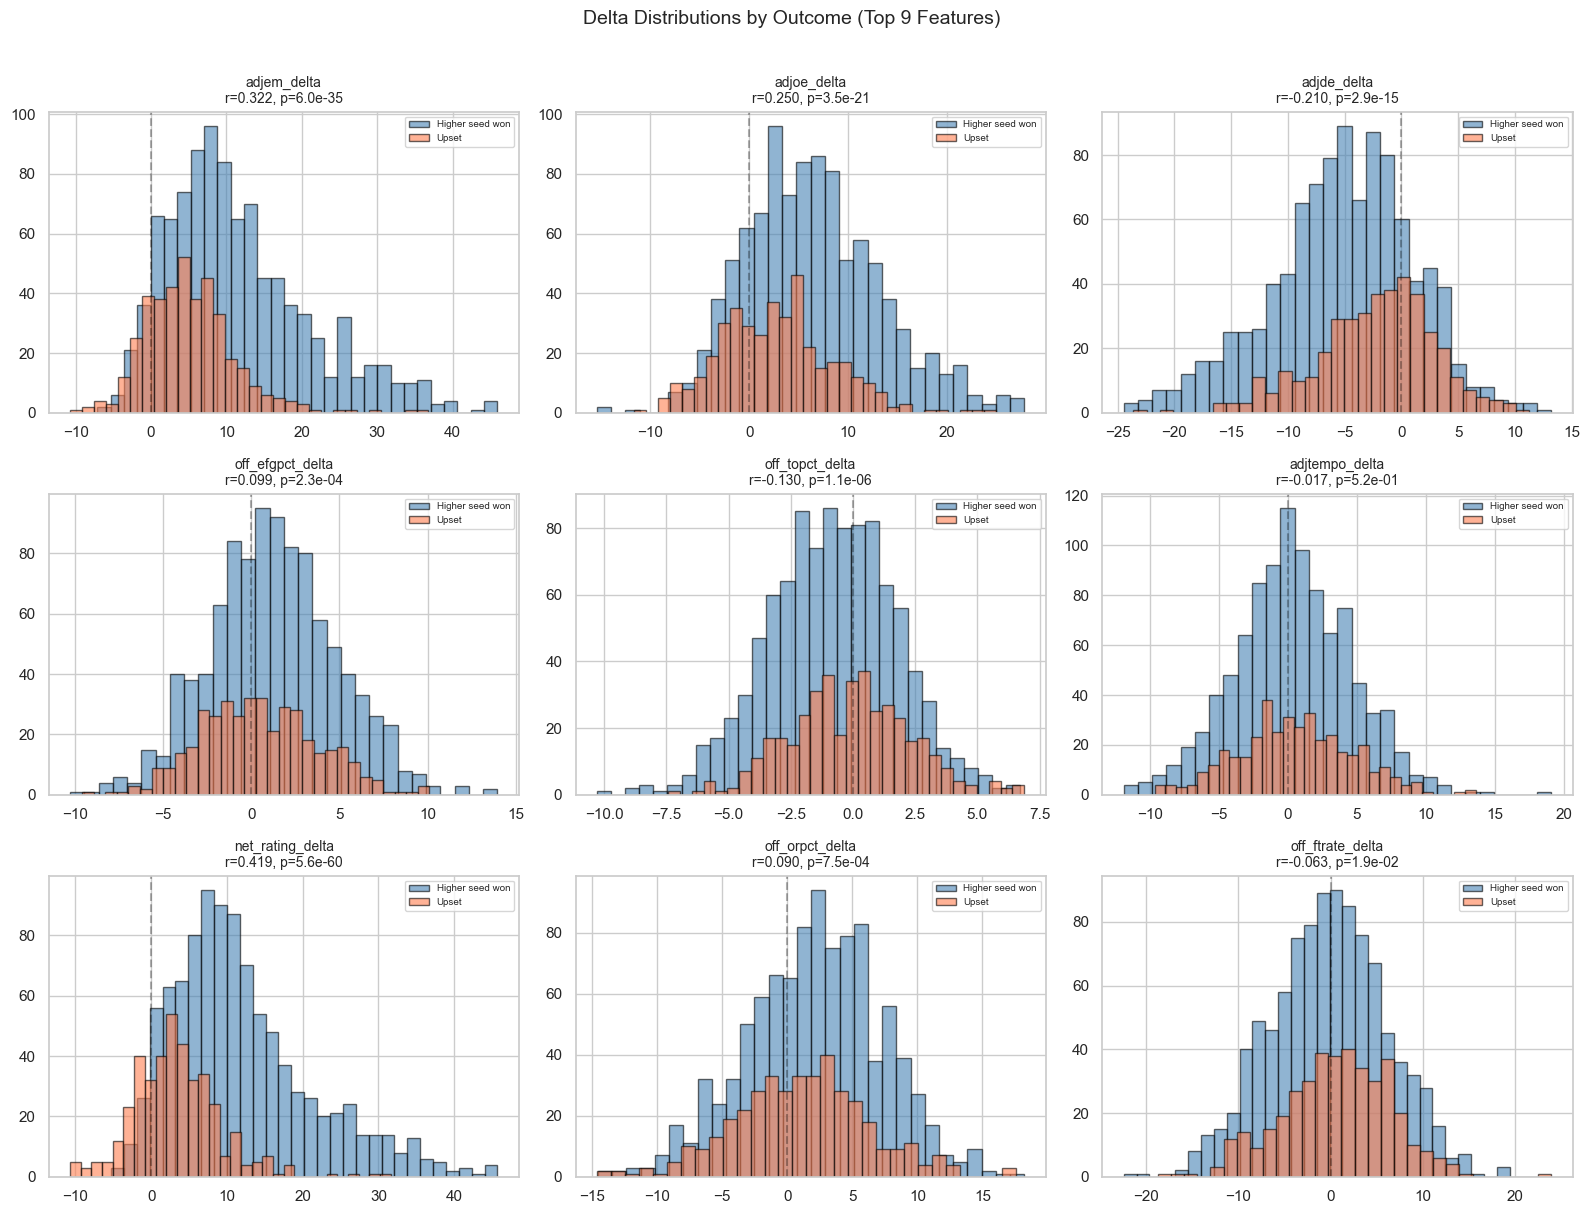

In [4]:
top9_deltas = [
    "adjem_delta", "adjoe_delta", "adjde_delta",
    "off_efgpct_delta", "off_topct_delta", "adjtempo_delta",
    "net_rating_delta", "off_orpct_delta", "off_ftrate_delta",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(top9_deltas):
    ax = axes[idx]
    for won, label, color in [(1, "Higher seed won", "steelblue"), (0, "Upset", "coral")]:
        subset = df_deltas[df_deltas["higher_seed_won"] == won]
        ax.hist(subset[col].dropna(), bins=30, alpha=0.6, label=label, color=color, edgecolor="black")

    # Annotate with Pearson r
    valid = df_deltas[[col, "higher_seed_won"]].dropna()
    r, p = pearsonr(valid[col], valid["higher_seed_won"])
    ax.set_title(f"{col}\nr={r:.3f}, p={p:.1e}", fontsize=10)
    ax.legend(fontsize=7)
    ax.axvline(0, color="black", linestyle="--", alpha=0.3)

fig.suptitle("Delta Distributions by Outcome (Top 9 Features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Expected Margin Analysis

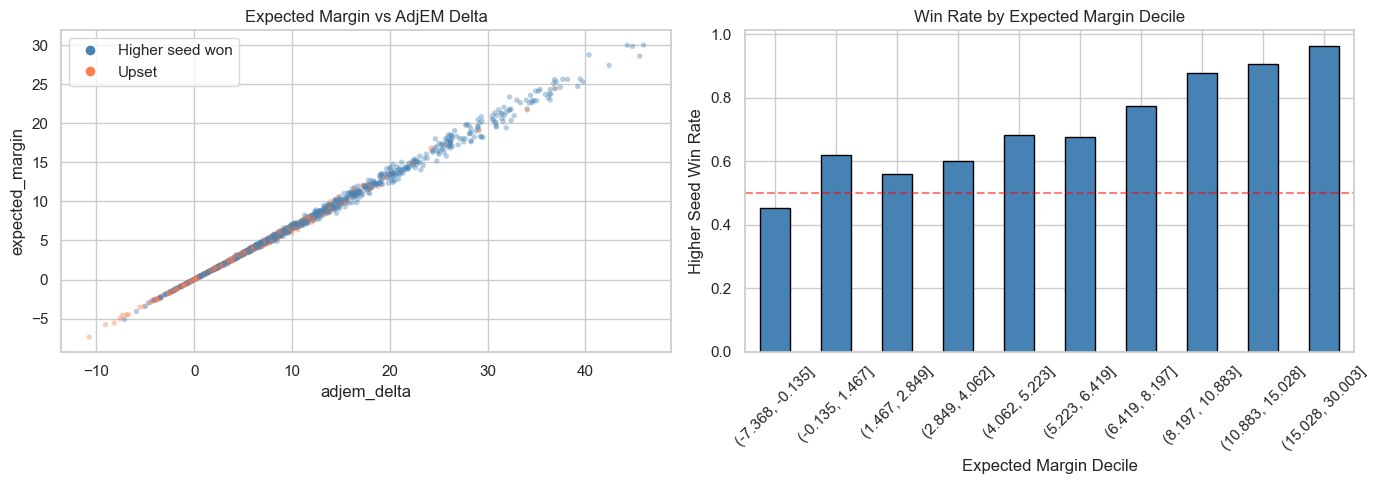

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: expected_margin vs adjem_delta colored by outcome
colors = df_deltas["higher_seed_won"].map({1: "steelblue", 0: "coral"})
axes[0].scatter(
    df_deltas["adjem_delta"], df_deltas["expected_margin"],
    c=colors, alpha=0.4, s=15, edgecolors="none",
)
axes[0].set_xlabel("adjem_delta")
axes[0].set_ylabel("expected_margin")
axes[0].set_title("Expected Margin vs AdjEM Delta")
# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="Higher seed won"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="coral", markersize=8, label="Upset"),
]
axes[0].legend(handles=legend_elements)

# Win rate by expected_margin decile
df_deltas["em_decile"] = pd.qcut(df_deltas["expected_margin"], q=10, duplicates="drop")
decile_rates = df_deltas.groupby("em_decile", observed=True)["higher_seed_won"].mean()
decile_rates.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Win Rate by Expected Margin Decile")
axes[1].set_ylabel("Higher Seed Win Rate")
axes[1].set_xlabel("Expected Margin Decile")
axes[1].axhline(0.5, color="red", linestyle="--", alpha=0.5)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Context Features

In [6]:
from src.features.context_features import build_upset_rate_lookup, add_context_features

# Build upset rate lookup from all data (this is exploration, not training)
upset_rate_lookup = build_upset_rate_lookup(df_deltas)
print(f"Upset rate lookup entries: {len(upset_rate_lookup)}")

# Add context features
df_ctx = add_context_features(df_deltas, upset_rate_lookup=upset_rate_lookup)

print(f"\nseed_diff range: [{df_ctx['seed_diff'].min()}, {df_ctx['seed_diff'].max()}]")
print(f"same_conf games: {df_ctx['same_conf'].sum()} / {len(df_ctx)} ({df_ctx['same_conf'].mean():.1%})")
print(f"hist_upset_rate range: [{df_ctx['hist_upset_rate'].min():.3f}, {df_ctx['hist_upset_rate'].max():.3f}]")
df_ctx[["seed_diff", "same_conf", "hist_upset_rate"]].describe().round(3)

INFO:src.features.context_features:Built upset rate lookup with 72 seed pairings
INFO:src.features.context_features:Added context features: seed_diff range [0, 15], 15 same-conf games


Upset rate lookup entries: 72

seed_diff range: [0, 15]
same_conf games: 15 / 1388 (1.1%)
hist_upset_rate range: [0.000, 1.000]


,seed_diff,same_conf,hist_upset_rate
count,1388.000,1388.000,1388.000
mean,6.380,0.011,0.288
std,4.228,0.103,0.176
min,0.000,0.000,0.000
25%,3.000,0.000,0.114
50%,7.000,0.000,0.302
75%,9.000,0.000,0.432
max,15.000,1.000,1.000


## 6. Upset Rate Heatmap

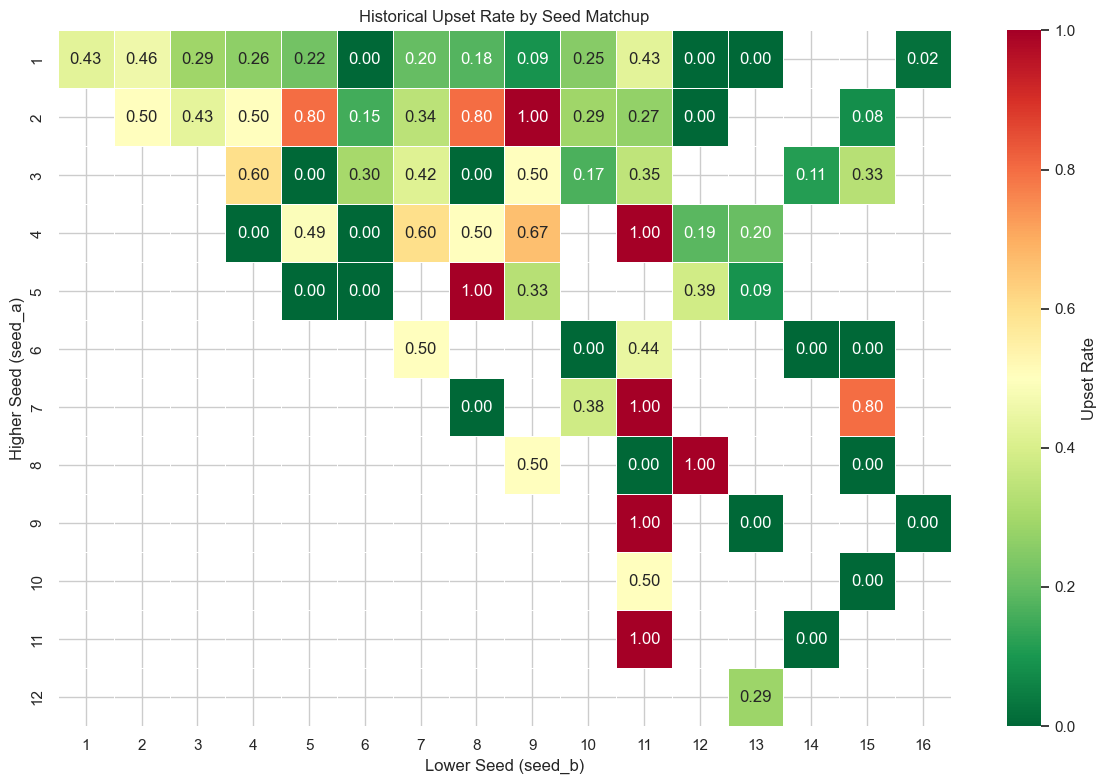

In [7]:
# Build a pivot table of upset rates by seed_a x seed_b
upset_df = pd.DataFrame(
    [(sa, sb, rate) for (sa, sb), rate in upset_rate_lookup.items()],
    columns=["seed_a", "seed_b", "upset_rate"],
)
pivot = upset_df.pivot(index="seed_a", columns="seed_b", values="upset_rate")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot, annot=True, cmap="RdYlGn_r", fmt=".2f",
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "Upset Rate"},
)
ax.set_title("Historical Upset Rate by Seed Matchup")
ax.set_xlabel("Lower Seed (seed_b)")
ax.set_ylabel("Higher Seed (seed_a)")

plt.tight_layout()
plt.show()

## 7. Context Feature Distributions

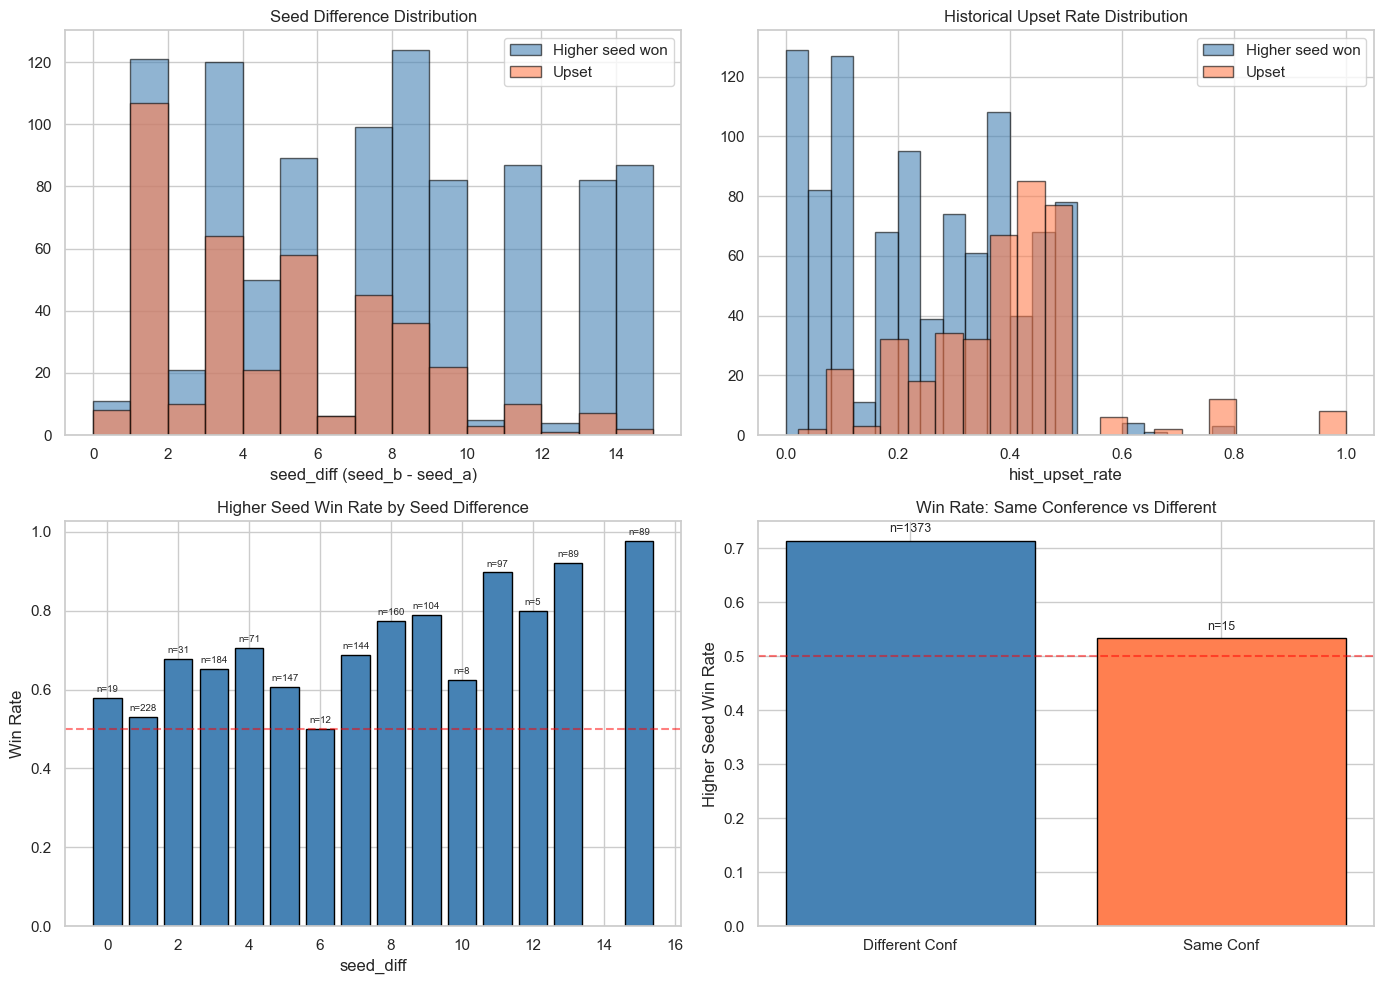

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# seed_diff histogram
for won, label, color in [(1, "Higher seed won", "steelblue"), (0, "Upset", "coral")]:
    subset = df_ctx[df_ctx["higher_seed_won"] == won]
    axes[0, 0].hist(subset["seed_diff"], bins=15, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0, 0].set_title("Seed Difference Distribution")
axes[0, 0].set_xlabel("seed_diff (seed_b - seed_a)")
axes[0, 0].legend()

# hist_upset_rate histogram
for won, label, color in [(1, "Higher seed won", "steelblue"), (0, "Upset", "coral")]:
    subset = df_ctx[df_ctx["higher_seed_won"] == won]
    axes[0, 1].hist(subset["hist_upset_rate"].dropna(), bins=20, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0, 1].set_title("Historical Upset Rate Distribution")
axes[0, 1].set_xlabel("hist_upset_rate")
axes[0, 1].legend()

# Win rate by seed_diff
win_by_diff = df_ctx.groupby("seed_diff")["higher_seed_won"].agg(["mean", "count"])
ax2 = axes[1, 0]
bars = ax2.bar(win_by_diff.index, win_by_diff["mean"], color="steelblue", edgecolor="black")
ax2.set_title("Higher Seed Win Rate by Seed Difference")
ax2.set_xlabel("seed_diff")
ax2.set_ylabel("Win Rate")
ax2.axhline(0.5, color="red", linestyle="--", alpha=0.5)
# Annotate with game counts
for bar, count in zip(bars, win_by_diff["count"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"n={int(count)}", ha="center", va="bottom", fontsize=7)

# Win rate: same_conf vs not
conf_rates = df_ctx.groupby("same_conf")["higher_seed_won"].agg(["mean", "count"])
conf_rates.index = ["Different Conf", "Same Conf"]
ax3 = axes[1, 1]
bars = ax3.bar(conf_rates.index, conf_rates["mean"], color=["steelblue", "coral"], edgecolor="black")
ax3.set_title("Win Rate: Same Conference vs Different")
ax3.set_ylabel("Higher Seed Win Rate")
ax3.axhline(0.5, color="red", linestyle="--", alpha=0.5)
for bar, count in zip(bars, conf_rates["count"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"n={int(count)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Ranking Targets

In [9]:
from src.features.ranking_criteria import compute_ranking_targets

df_ranked = compute_ranking_targets(df_ctx, upset_rate_lookup=upset_rate_lookup)

ranking_cols = ["seed_implied_prob", "efficiency_delta_rank", "game_certainty_score"]
print("Ranking target summary:")
print(df_ranked[ranking_cols].describe().round(3))

# Pairwise Spearman correlation matrix of ranking targets
print("\nPairwise Spearman correlations:")
spearman_matrix = df_ranked[ranking_cols].corr(method="spearman")
print(spearman_matrix.round(3))

INFO:src.features.ranking_criteria:Added ranking targets: seed_implied_prob [0.00, 1.00], efficiency_delta_rank [0.00, 1.00], game_certainty_score [0.18, 0.98]


Ranking target summary:
       seed_implied_prob  efficiency_delta_rank  game_certainty_score
count           1388.000               1388.000              1388.000
mean               0.712                  0.222                 0.484
std                0.176                  0.190                 0.162
min                0.000                  0.000                 0.178
25%                0.568                  0.079                 0.354
50%                0.698                  0.174                 0.457
75%                0.886                  0.303                 0.572
max                1.000                  1.000                 0.981

Pairwise Spearman correlations:
                       seed_implied_prob  efficiency_delta_rank  \
seed_implied_prob                  1.000                  0.704   
efficiency_delta_rank              0.704                  1.000   
game_certainty_score               0.767                  0.848   

                       game_certainty_score 

## 9. Ranking Target Distributions

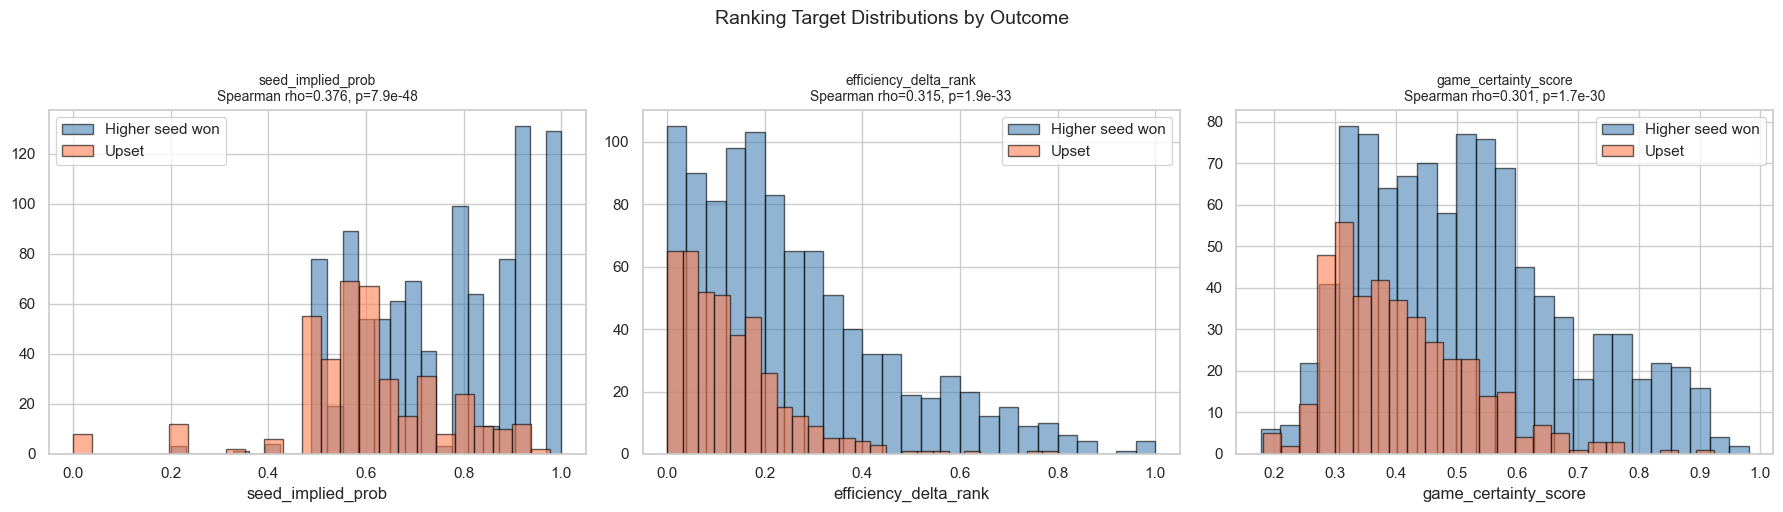

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(ranking_cols):
    ax = axes[idx]
    for won, label, color in [(1, "Higher seed won", "steelblue"), (0, "Upset", "coral")]:
        subset = df_ranked[df_ranked["higher_seed_won"] == won]
        ax.hist(subset[col].dropna(), bins=25, alpha=0.6, label=label, color=color, edgecolor="black")

    # Annotate with Spearman r vs outcome
    valid = df_ranked[[col, "higher_seed_won"]].dropna()
    rho, p = spearmanr(valid[col], valid["higher_seed_won"])
    ax.set_title(f"{col}\nSpearman rho={rho:.3f}, p={p:.1e}", fontsize=10)
    ax.set_xlabel(col)
    ax.legend()

fig.suptitle("Ranking Target Distributions by Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Full Pipeline + Leakage-Safe Split

In [11]:
from src.features.pipeline import build_features, build_features_for_split
from src.config import FIRST_YEAR, LAST_YEAR, SKIP_YEARS

# Full pipeline (all data, no split)
fs_full = build_features(merged_df=merged)
print("Full FeatureSet:")
print(f"  X shape: {fs_full.X.shape}")
print(f"  y shape: {fs_full.y.shape}")
print(f"  meta shape: {fs_full.meta.shape}")
print(f"  ranking_targets shape: {fs_full.ranking_targets.shape}")
print(f"  feature_names ({len(fs_full.feature_names)}): {fs_full.feature_names}")
print(f"  gating_features: {fs_full.gating_features}")

# Leakage-safe split: hold out 2025 as test
all_seasons = [y for y in range(FIRST_YEAR, LAST_YEAR + 1) if y not in SKIP_YEARS]
train_seasons = [y for y in all_seasons if y != 2025]
test_seasons = [2025]

train_fs, test_fs = build_features_for_split(train_seasons, test_seasons, merged_df=merged)
print(f"\nLeakage-safe split (test=2025):")
print(f"  Train: X={train_fs.X.shape}, y={train_fs.y.shape}")
print(f"  Test:  X={test_fs.X.shape}, y={test_fs.y.shape}")

# Verify same column sets
assert list(train_fs.X.columns) == list(test_fs.X.columns), "Column mismatch!"
print(f"  Columns match: True ({len(train_fs.feature_names)} features)")

# Verify no season leakage
train_years = set(train_fs.meta["season"].unique())
test_years = set(test_fs.meta["season"].unique())
assert train_years.isdisjoint(test_years), "Season leakage detected!"
print(f"  No season leakage: True")

INFO:src.features.pipeline:Building features from 1388 games
INFO:src.features.kenpom_deltas:Detected 34 stat pairs for deltas: ['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'sos_adjem', 'sos_opp_d', 'sos_opp_o']
INFO:src.features.kenpom_deltas:Computed 34 delta columns
INFO:src.features.kenpom_deltas:Added expected_margin feature
INFO:src.features.context_features:Built upset rate lookup with 72 seed pairings
INFO:src.features.context_features:Added context features: seed_diff range [0, 15], 15 same-conf games
INFO:src.features.ranking_criteria:Added ranking targets: seed_implied_prob [0.00, 1.00], efficiency_delta_rank [0.00

Full FeatureSet:
  X shape: (1388, 39)
  y shape: (1388,)
  meta shape: (1388, 11)
  ranking_targets shape: (1388, 3)
  feature_names (39): ['adjde_delta', 'adjem_delta', 'adjoe_delta', 'adjtempo_delta', 'avg_height_delta', 'bench_delta', 'def_arate_delta', 'def_blockpct_delta', 'def_fg2pct_delta', 'def_fg3pct_delta', 'def_fg3rate_delta', 'def_ftpct_delta', 'def_nstrate_delta', 'def_stlrate_delta', 'eff_height_delta', 'expected_margin', 'experience_delta', 'hist_upset_rate', 'luck_delta', 'ncsos_adjem_delta', 'net_rating_delta', 'off_arate_delta', 'off_blockpct_delta', 'off_efgpct_delta', 'off_fg2pct_delta', 'off_fg3pct_delta', 'off_fg3rate_delta', 'off_ftpct_delta', 'off_ftrate_delta', 'off_nstrate_delta', 'off_orpct_delta', 'off_stlrate_delta', 'off_topct_delta', 'round', 'same_conf', 'seed_diff', 'sos_adjem_delta', 'sos_opp_d_delta', 'sos_opp_o_delta']
  gating_features: ['seed_diff', 'round', 'adjem_delta', 'luck_delta']


INFO:src.features.context_features:Added context features: seed_diff range [0, 15], 15 same-conf games
INFO:src.features.ranking_criteria:Added ranking targets: seed_implied_prob [0.00, 1.00], efficiency_delta_rank [0.00, 1.00], game_certainty_score [0.18, 0.98]
INFO:src.features.pipeline:Partitioned: 39 feature cols, 11 meta cols, 3 ranking targets
INFO:src.features.pipeline:Building features from 63 games
INFO:src.features.kenpom_deltas:Detected 34 stat pairs for deltas: ['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'sos_adjem', 'sos_opp_d', 'sos_opp_o']
INFO:src.features.kenpom_deltas:Computed 34 delta columns
INFO:src.feat


Leakage-safe split (test=2025):
  Train: X=(1325, 39), y=(1325,)
  Test:  X=(63, 39), y=(63,)
  Columns match: True (39 features)
  No season leakage: True


## 11. Feature Correlation Heatmap

Top 20 features by |corr| with higher_seed_won:
  net_rating_delta: 0.4185
  hist_upset_rate: -0.3883
  expected_margin: 0.3229
  adjem_delta: 0.3224
  sos_adjem_delta: 0.3000
  sos_opp_o_delta: 0.2889
  sos_opp_d_delta: -0.2886
  seed_diff: 0.2820
  adjoe_delta: 0.2497
  adjde_delta: -0.2098
  off_topct_delta: -0.1305
  def_fg3pct_delta: -0.1286
  def_nstrate_delta: -0.1072
  off_nstrate_delta: -0.1059
  off_efgpct_delta: 0.0987
  avg_height_delta: 0.0986
  off_orpct_delta: 0.0904
  off_blockpct_delta: 0.0894
  off_fg2pct_delta: 0.0860
  def_stlrate_delta: -0.0840


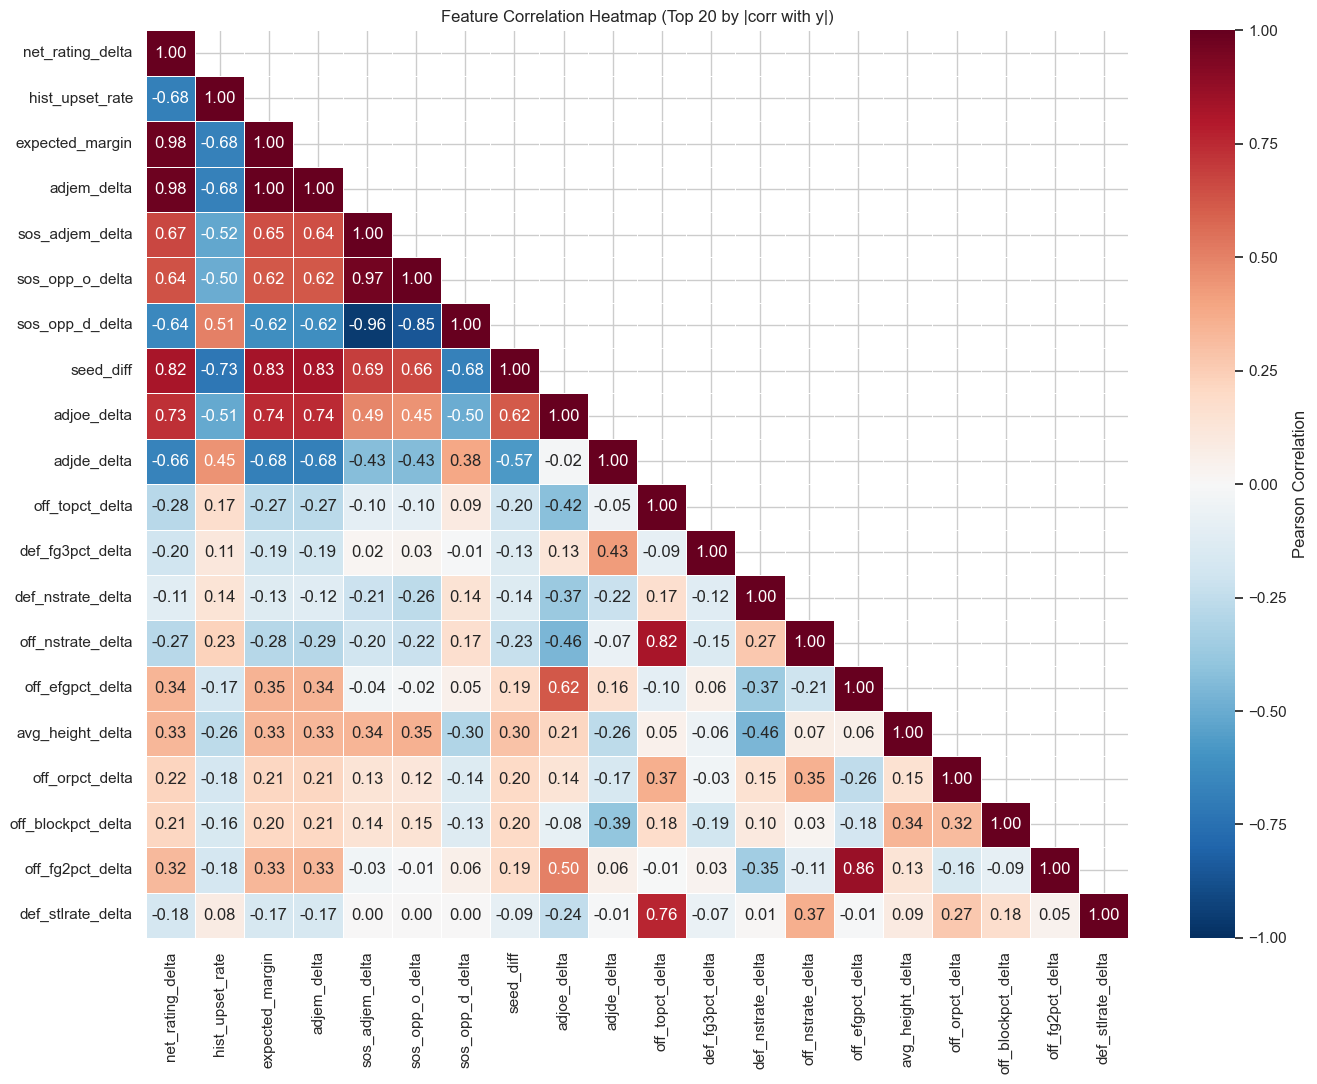

In [12]:
# Compute correlations of all features with y
corr_with_y = fs_full.X.corrwith(fs_full.y).abs().sort_values(ascending=False)
top20_features = corr_with_y.head(20).index.tolist()

print(f"Top 20 features by |corr| with higher_seed_won:")
for feat in top20_features:
    print(f"  {feat}: {fs_full.X[feat].corr(fs_full.y):.4f}")

# Heatmap of top 20 feature inter-correlations
corr_matrix = fs_full.X[top20_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson Correlation"},
)
ax.set_title("Feature Correlation Heatmap (Top 20 by |corr with y|)")

plt.tight_layout()
plt.show()

## 12. Gating Feature Relationships

Gating features: ['seed_diff', 'round', 'adjem_delta', 'luck_delta']


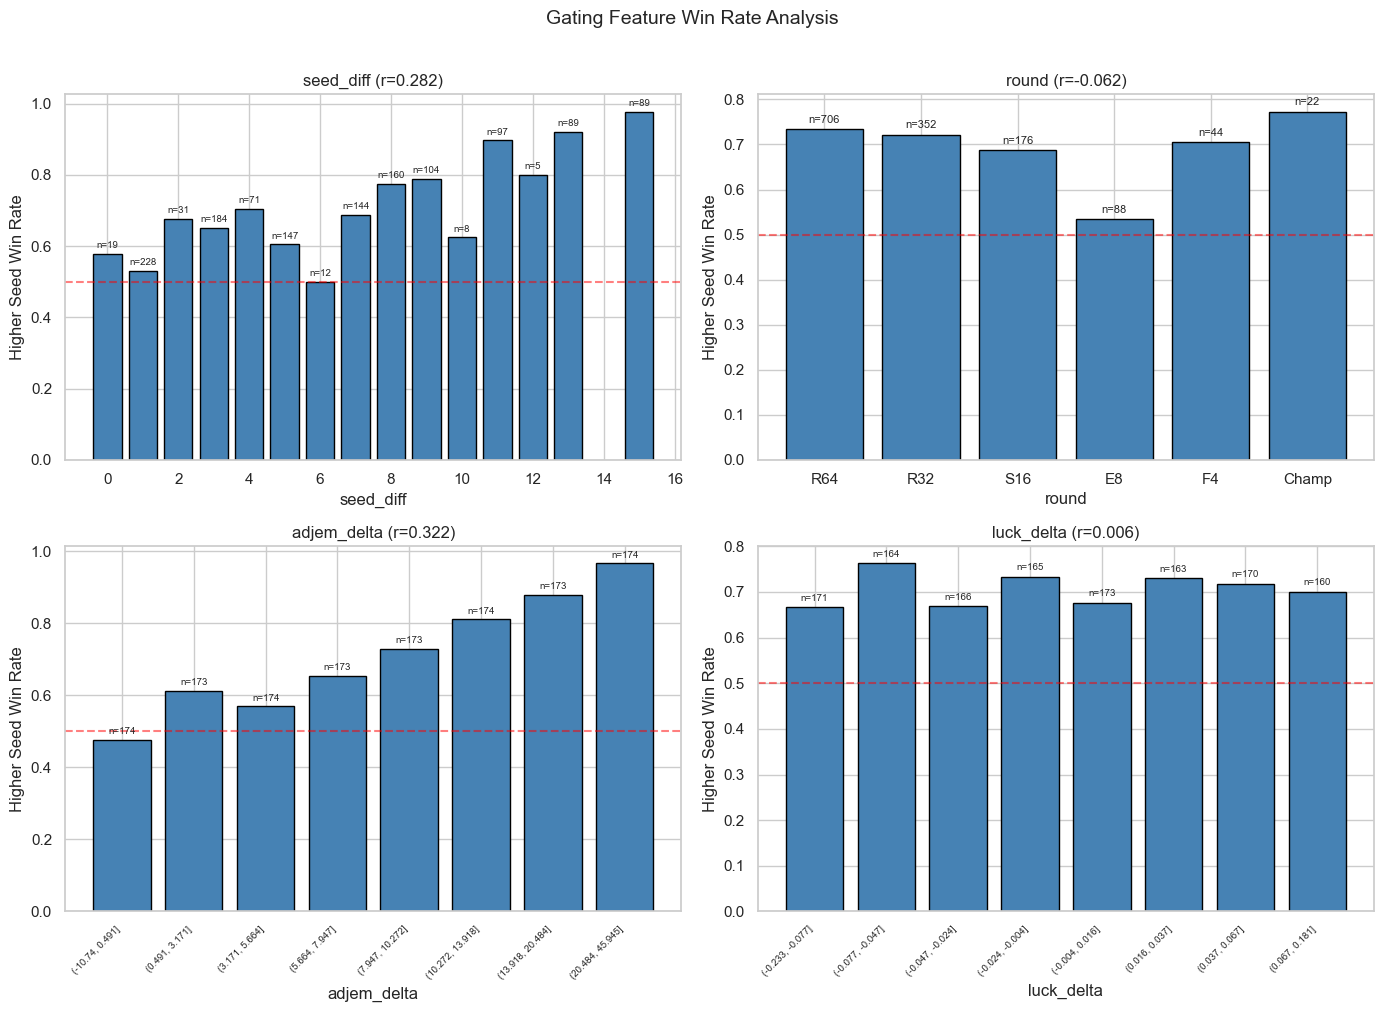

In [13]:
gating_features = fs_full.gating_features  # ["seed_diff", "round", "adjem_delta", "luck_delta"]
print(f"Gating features: {gating_features}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Combine X and y for analysis
gating_df = fs_full.X[gating_features].copy()
gating_df["higher_seed_won"] = fs_full.y.values

for idx, feat in enumerate(gating_features):
    ax = axes[idx]
    valid = gating_df[[feat, "higher_seed_won"]].dropna()

    if feat == "round":
        # Round is discrete: bar chart directly
        grouped = valid.groupby(feat)["higher_seed_won"].agg(["mean", "count"])
        bars = ax.bar(grouped.index, grouped["mean"], color="steelblue", edgecolor="black")
        ax.set_xticks(grouped.index)
        ax.set_xticklabels(["R64", "R32", "S16", "E8", "F4", "Champ"][:len(grouped)])
        for bar, count in zip(bars, grouped["count"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"n={int(count)}", ha="center", va="bottom", fontsize=8)
    elif feat == "seed_diff":
        # seed_diff is discrete-ish: bar chart
        grouped = valid.groupby(feat)["higher_seed_won"].agg(["mean", "count"])
        bars = ax.bar(grouped.index, grouped["mean"], color="steelblue", edgecolor="black")
        for bar, count in zip(bars, grouped["count"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"n={int(count)}", ha="center", va="bottom", fontsize=7)
    else:
        # Continuous: bin into 8 groups
        valid["bin"] = pd.qcut(valid[feat], q=8, duplicates="drop")
        grouped = valid.groupby("bin", observed=True)["higher_seed_won"].agg(["mean", "count"])
        bars = ax.bar(range(len(grouped)), grouped["mean"], color="steelblue", edgecolor="black")
        ax.set_xticks(range(len(grouped)))
        ax.set_xticklabels([str(x) for x in grouped.index], rotation=45, ha="right", fontsize=7)
        for bar, count in zip(bars, grouped["count"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"n={int(count)}", ha="center", va="bottom", fontsize=7)

    r_val = valid[feat].corr(valid["higher_seed_won"])
    ax.set_title(f"{feat} (r={r_val:.3f})")
    ax.set_ylabel("Higher Seed Win Rate")
    ax.set_xlabel(feat)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)

fig.suptitle("Gating Feature Win Rate Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()